In [1]:
import os
import sys
import pathlib
import numpy as np
import copy

from pymdp.agent import Agent
from pymdp.utils import plot_beliefs, plot_likelihood
from pymdp import utils
from pymdp.envs import TMazeEnv

In [2]:
reward_probabilities = [0.98, 0.02] # probabilities used in the original SPM T-maze demo
env = TMazeEnv(reward_probs = reward_probabilities)

In [3]:
# here, we can get the likelihood mapping directly from the environmental class. So this is the likelihood mapping that truly describes the relatinoship between the 
# environment's hidden state and the observations the agent will get

A_gp = env.get_likelihood_dist()

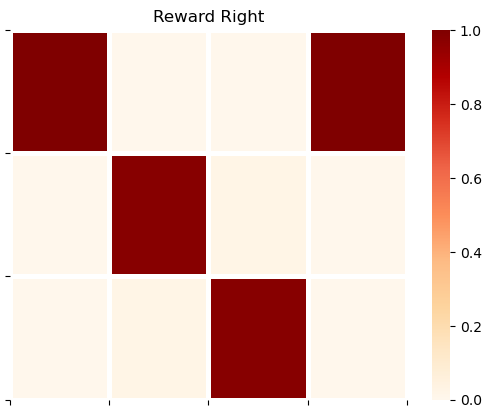

In [4]:
plot_likelihood(A_gp[1][:,:,0],'Reward Right')


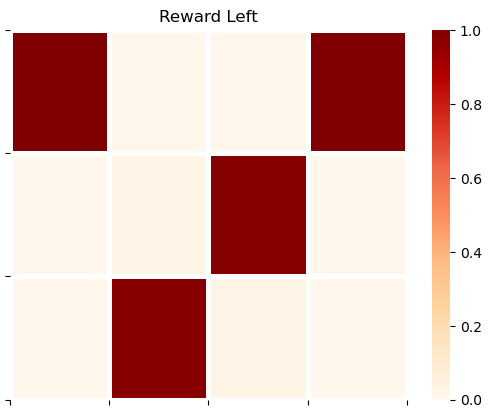

In [6]:
plot_likelihood(A_gp[1][:,:,1],'Reward Left')

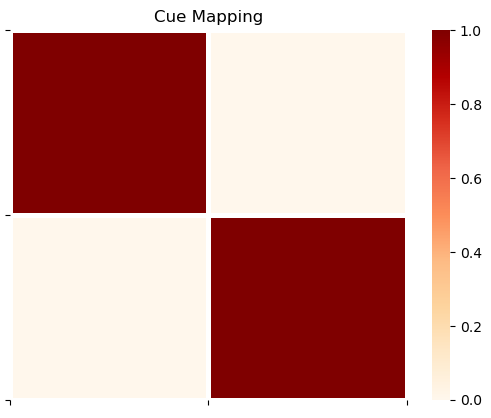

In [9]:
plot_likelihood(A_gp[2][:,3,:],'Cue Mapping')

In [8]:
env.num_factors

2

In [10]:
grid_dims = [5, 7] # dimensions of the grid (number of rows, number of columns)
num_grid_points = np.prod(grid_dims) # total number of grid locations (rows X columns)

# create a look-up table `loc_list` that maps linear indices to tuples of (y, x) coordinates 
grid = np.arange(num_grid_points).reshape(grid_dims)
it = np.nditer(grid, flags=["multi_index"])

In [11]:
grid

array([[ 0,  1,  2,  3,  4,  5,  6],
       [ 7,  8,  9, 10, 11, 12, 13],
       [14, 15, 16, 17, 18, 19, 20],
       [21, 22, 23, 24, 25, 26, 27],
       [28, 29, 30, 31, 32, 33, 34]])

In [12]:
it

In [14]:
it.itviews

(array([[ 0,  1,  2,  3,  4,  5,  6],
        [ 7,  8,  9, 10, 11, 12, 13],
        [14, 15, 16, 17, 18, 19, 20],
        [21, 22, 23, 24, 25, 26, 27],
        [28, 29, 30, 31, 32, 33, 34]]),)

In [15]:
loc_list = []
while not it.finished:
    loc_list.append(it.multi_index)
    it.iternext()

In [16]:
loc_list


[(0, 0),
 (0, 1),
 (0, 2),
 (0, 3),
 (0, 4),
 (0, 5),
 (0, 6),
 (1, 0),
 (1, 1),
 (1, 2),
 (1, 3),
 (1, 4),
 (1, 5),
 (1, 6),
 (2, 0),
 (2, 1),
 (2, 2),
 (2, 3),
 (2, 4),
 (2, 5),
 (2, 6),
 (3, 0),
 (3, 1),
 (3, 2),
 (3, 3),
 (3, 4),
 (3, 5),
 (3, 6),
 (4, 0),
 (4, 1),
 (4, 2),
 (4, 3),
 (4, 4),
 (4, 5),
 (4, 6)]